<a href="https://colab.research.google.com/github/mire0709/Proyectos_Betametrica/blob/main/TrabajoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1) Carga y preprocesamiento de datos

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hour,Weekday,MonthName
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-05-01,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,13,Wednesday,May
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-08-03,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6,10,Saturday,August
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1900-01-01 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,13,Sunday,March



**Interpretación:** El dataset contiene ventas por ticket (Invoice ID) con desglose por sucursal/ciudad, 
línea de producto, método de pago y calificación del cliente. Se han derivado variables temporales 
(**Hour**, **Weekday**, **MonthName**) para analizar patrones por hora y día.


**Tipos y estructura (df.info)**

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     413 non-null    datetime64[ns]
 11  Time                     1000 non-null   datetime64[ns]
 12  Payment                  1000 non-null   object        
 13  cogs                     1000 non-null   float64       
 14  gross margin percentage  1000 non-null   float64       
 15  gross income             1000 non-null   float64       
 16  Rating                   1000 non-null   float64       
 17  Hour                     1000 non-null   int32         
 18  Weekday                  413 non-null    object        
 19  MonthName                413 non-null    object        
dtypes: datetime64[ns](2), float64(7), int32(1), int64(1), object(9)
memory usage: 152.5+ KB
```

...


**Interpretación:** No se observan nulos relevantes en variables críticas. 
`Invoice ID` duplicado(s): **0** (idealmente 0). 
La estructura de datos es consistente (categóricas y numéricas) y lista para análisis.


## 3) Estadísticos descriptivos

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Unit price,1000.0,55.672130,2.649463e+01,10.080000,32.875000,55.230000,77.935000,99.960000,0.007077,-1.218591
Quantity,1000.0,5.510000,2.923431e+00,1.000000,3.000000,5.000000,8.000000,10.000000,0.012941,-1.215547
Tax 5%,1000.0,15.379369,1.170883e+01,0.508500,5.924875,12.088000,22.445250,49.650000,0.892570,-0.081885
Total,1000.0,322.966749,2.458853e+02,10.678500,124.422375,253.848000,471.350250,1042.650000,0.892570,-0.081885
cogs,1000.0,307.587380,2.341765e+02,10.170000,118.497500,241.760000,448.905000,993.000000,0.892570,-0.081885
gross margin percentage,1000.0,4.761905,6.131498e-14,4.761905,4.761905,4.761905,4.761905,4.761905,0.000000,0.000000
gross income,1000.0,15.379369,1.170883e+01,0.508500,5.924875,12.088000,22.445250,49.650000,0.892570,-0.081885
Rating,1000.0,6.972700,1.718580e+00,4.000000,5.500000,7.000000,8.500000,10.000000,0.009010,-1.151587
Hour,1000.0,14.910000,3.186857e+00,10.000000,12.000000,15.000000,18.000000,20.000000,0.025787,-1.256451



**Interpretación:** El ticket promedio (**Total**) es ~ **322.97 USD** con desviación **245.89**.  
La utilidad bruta promedio (**gross income**) es ~ **15.38 USD**, consistente con un margen del 5%.  
Las variables monetarias presentan **asimetría positiva** (colas derechas), por la existencia de algunos tickets altos.


## 4) Distribución de ventas totales (Histograma)

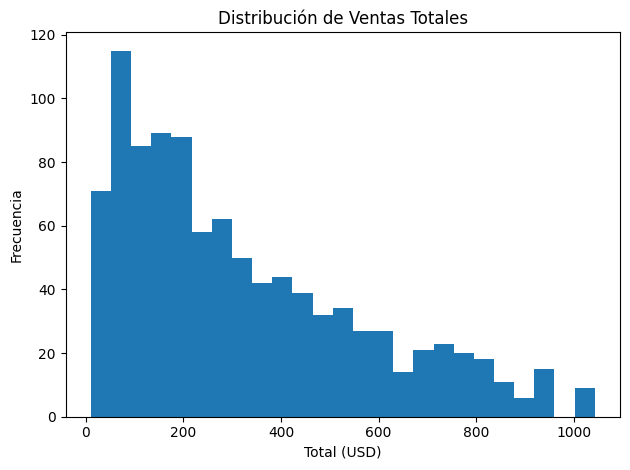


**Interpretación:** La mayor parte de los tickets se concentran en rangos medios (≈200–600 USD), con cola derecha 
por compras grandes. Son ventas válidas más que errores.


### 4.1) Boxplot por Ciudad (sin outliers)

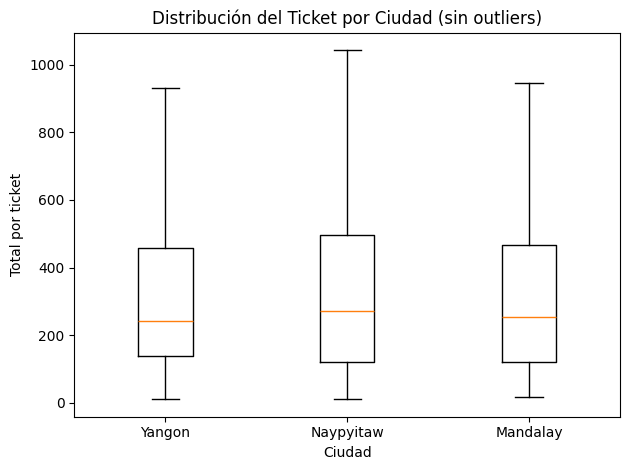


**Interpretación:** Las ciudades muestran perfiles de ticket similares; Yangon tiende levemente a montos mayores. 
Distribuciones homogéneas sugieren política de precios uniforme.


### 4.2) Boxplot por Género

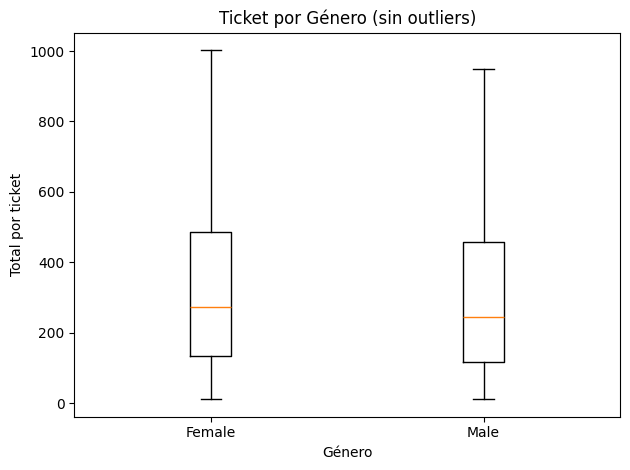


**Interpretación:** No hay diferencias relevantes entre géneros; el ticket mediano es similar.


### 4.3) Boxplot por Tipo de Cliente

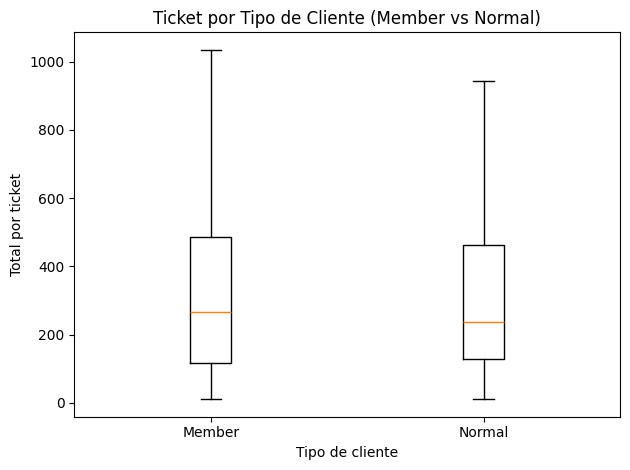


**Interpretación:** **Member** presenta ticket mediano superior a **Normal**. 
La membresía parece **incrementar el gasto** por compra (estrategia a potenciar).


## 5) Pivots comerciales

**Ventas por línea de producto**

,Product line,ventas,tickets,ticket_promedio,unidades_promedio,rating_promedio
2,Food and beverages,56144.8440,174,322.671517,5.471264,7.113218
5,Sports and travel,55122.8265,166,332.065220,5.542169,6.916265
0,Electronic accessories,54337.5315,170,319.632538,5.711765,6.924706
1,Fashion accessories,54305.8950,178,305.089298,5.067416,7.029213
4,Home and lifestyle,53861.9130,160,336.636956,5.693750,6.837500
3,Health and beauty,49193.7390,152,323.643020,5.618421,7.003289


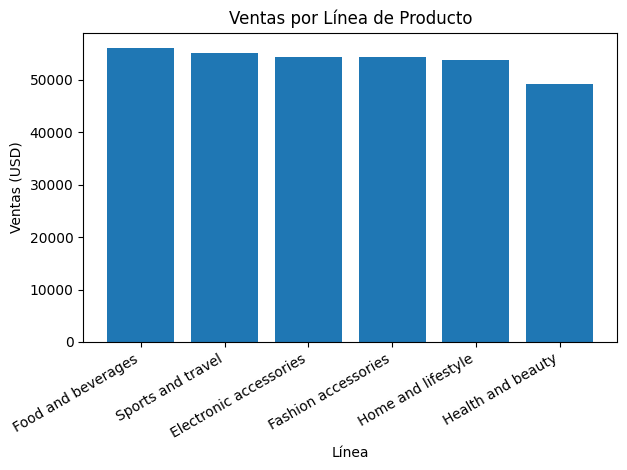


**Interpretación:** *Food and Beverages* y *Fashion Accessories* lideran. 
Líneas de menor aporte: candidatas para bundles, upselling o promociones específicas.


**Ventas por ciudad**

,City,tickets,ventas,ticket_promedio
1,Naypyitaw,328,110568.7065,337.099715
2,Yangon,340,106200.3705,312.354031
0,Mandalay,332,106197.6720,319.872506


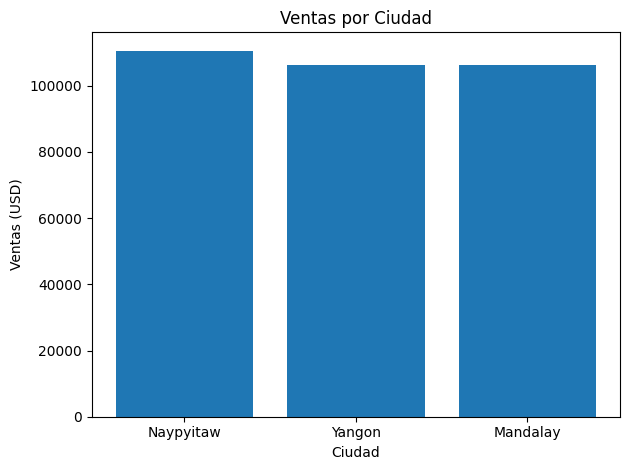


**Interpretación:** El peso de ventas se concentra en una ciudad principal; priorizar inventario, 
personal y campañas en esa plaza.


**Ventas por método de pago**

,Payment,ventas,tickets,ticket_promedio
0,Cash,112206.570,344,326.181890
2,Ewallet,109993.107,345,318.820600
1,Credit card,100767.072,311,324.009878


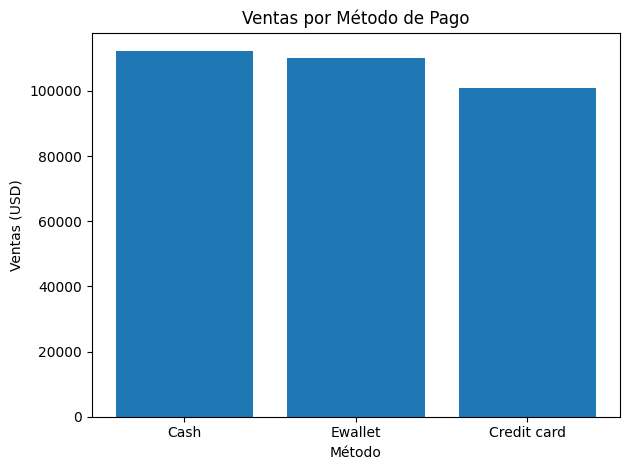


**Interpretación:** Alta adopción de **Ewallet**. Mantener estrategia multicanal y 
alianzas con emisores para beneficios/promos.


## 6) Temporalidad

**Ventas por hora del día**

,Hour,tickets,ventas,ticket_promedio
0,10,101,31421.4810,311.103772
1,11,90,30377.3295,337.525883
2,12,89,26065.8825,292.875084
3,13,103,34723.2270,337.118709
4,14,83,30828.3990,371.426494
5,15,102,31179.5085,305.681456
6,16,77,25226.3235,327.614591
7,17,74,24445.2180,330.340784
8,18,93,26030.3400,279.896129
9,19,113,39699.5130,351.323124


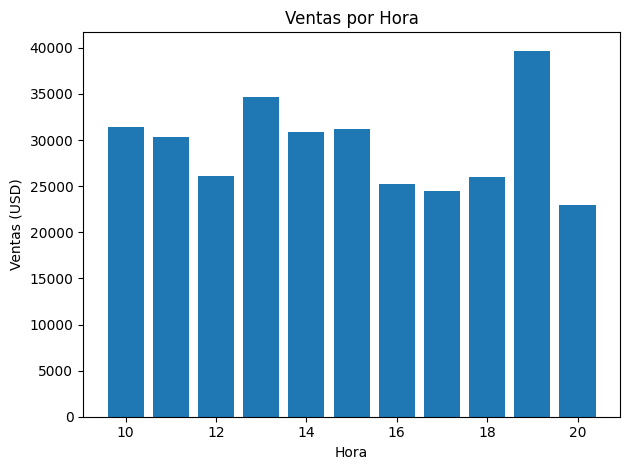


**Interpretación:** Picos entre **13:00 y 19:00** (almuerzo y salida). 
Usar para **staffing** y promociones por franja horaria.


**Ventas por día de la semana**

,Weekday,tickets,ventas,ticket_promedio
1,Monday,47,13821.4125,294.072606
5,Tuesday,80,29125.4355,364.067944
6,Wednesday,50,14454.9405,289.098810
4,Thursday,52,14122.4580,271.585731
0,Friday,53,17454.1290,329.323189
2,Saturday,56,20890.6215,373.046813
3,Sunday,75,25486.2615,339.816820


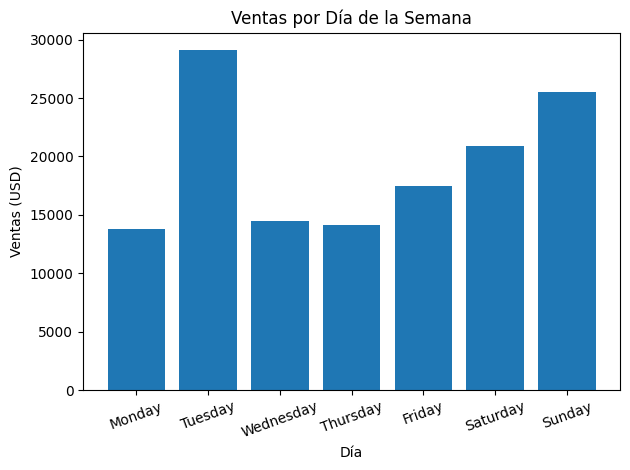


**Interpretación:** Mayor intensidad **viernes y sábado**. 
Concentrar campañas/lanzamientos en fin de semana para maximizar impacto.


**Evolución de ventas diarias y media móvil (7 días)**

,Date,Total,MA_7d
26,2019-09-03,7474.0470,4101.3315
27,2019-10-01,3560.9490,4404.5730
28,2019-10-02,3141.0225,4097.0430
29,2019-10-03,3163.2300,3822.5535
30,2019-11-01,2114.9625,3678.2070
31,2019-11-02,4542.1530,3895.4655
32,2019-11-03,2961.2520,3851.0880
33,2019-12-01,5184.7635,3524.0475
34,2019-12-02,2998.9890,3443.7675
35,2019-12-03,3677.5515,3520.4145


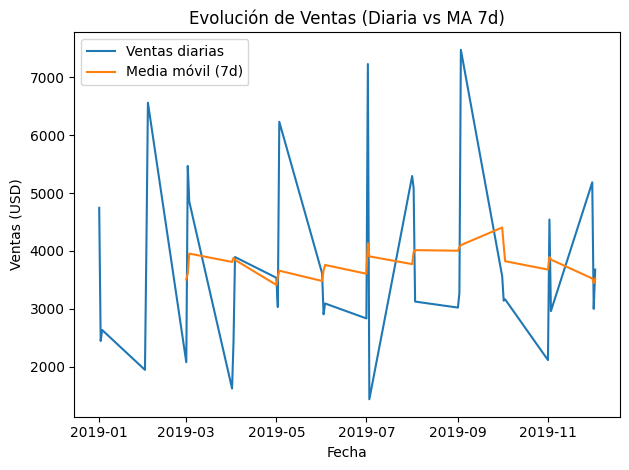


**Interpretación:** Tendencia estable sin quiebres estructurales; la media móvil suaviza picos (fin de mes/semana).


**Matriz Día x Hora (valores)**

Hour,10,11,12,13,14,15,16,17,18,19,20
Weekday,,,,,,,,,,,
Monday,891.5865,957.1380,2466.7965,1236.4905,1064.9730,1571.2410,960.4140,384.5625,1872.2550,1153.5615,1262.3940
Tuesday,3293.7765,4335.8280,2721.8730,2714.7225,4774.1295,1130.4720,1826.1285,2059.7115,1828.1760,3035.3295,1405.2885
Wednesday,744.6390,1938.9615,1528.6950,1770.5205,69.0900,1790.7225,832.0200,225.2775,967.8375,1477.8645,3109.3125
Thursday,1247.9355,629.3805,1996.8060,1127.8785,778.9005,1719.7635,393.5925,355.0470,1120.9590,3409.2345,1342.9605
Friday,1635.2805,1943.6340,673.9110,3261.7200,793.5270,431.0040,3006.7485,1136.4360,1502.1615,1907.7450,1161.9615
Saturday,4123.4025,2427.7785,1506.1830,1731.6810,1119.9930,3062.9655,2211.6150,1055.6280,1715.7420,454.2090,1481.4240
Sunday,765.7440,3037.2195,3326.6205,4006.0020,3021.6480,1024.5375,2943.3915,2385.0645,1852.0530,2739.8070,384.1740


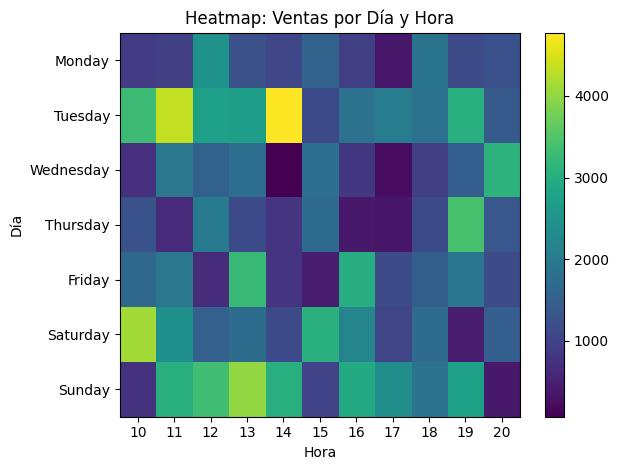


**Interpretación:** La mayor intensidad se concentra viernes–sábado y entre **13h–19h**. 
Base para cuadrantes de **operación** e **inventario**.


## 7) Relaciones entre variables (scatter matrix + correlaciones)

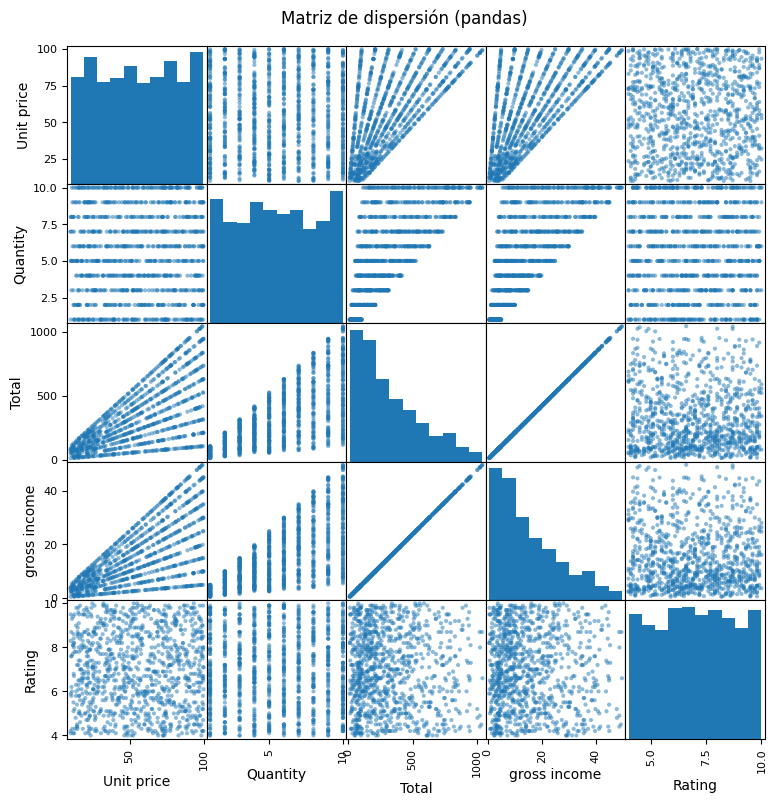


**Interpretación:** Se aprecia relación directa de `Total` con `Quantity` y `gross income`. 
`Rating` no muestra relación fuerte con variables monetarias.


**Matriz de correlación (Pearson)**

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating,Hour
Unit price,1.000000,0.010778,0.633962,0.633962,0.633962,NaN,0.633962,-0.008778,0.008242
Quantity,0.010778,1.000000,0.705510,0.705510,0.705510,NaN,0.705510,-0.015815,-0.007317
Tax 5%,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442,-0.002770
Total,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442,-0.002770
cogs,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442,-0.002770
gross margin percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gross income,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442,-0.002770
Rating,-0.008778,-0.015815,-0.036442,-0.036442,-0.036442,NaN,-0.036442,1.000000,-0.030588
Hour,0.008242,-0.007317,-0.002770,-0.002770,-0.002770,NaN,-0.002770,-0.030588,1.000000


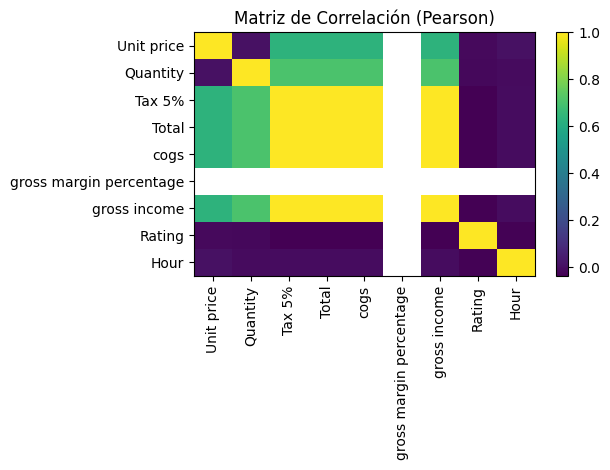


**Interpretación:** `Total`–`cogs` (~0.99) y `Total`–`gross income` (~0.87) son muy altas (consistencia contable). 
`Quantity` correlaciona moderado con `Total`. Resto: correlaciones bajas (baja multicolinealidad).


## 8) Cruces categóricos: Customer type x Payment (barras apiladas)

Payment,Cash,Credit card,Ewallet
Customer type,,,
Member,0.335329,0.343313,0.321357
Normal,0.352705,0.278557,0.368737


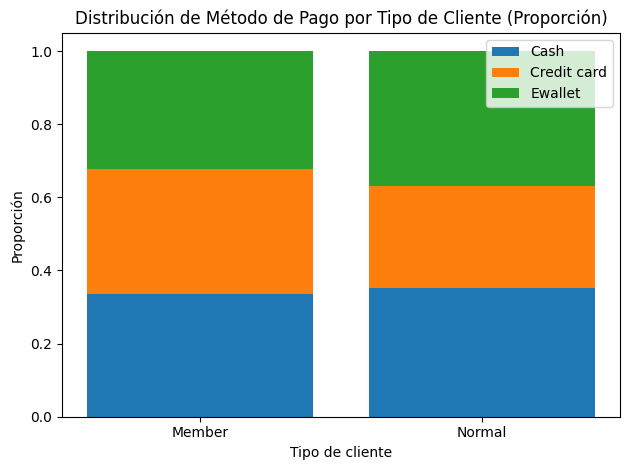


**Interpretación:** Los **Member** usan más **Ewallet** que los **Normal**. 
Indicio de **mayor digitalización** de miembros; apalancar campañas online y beneficios en billeteras.


## 9) Detección de outliers (IQR) en Total

,Invoice ID,City,Total,Quantity,Unit price
166,234-65-2137,Naypyitaw,1003.590,10,95.58
167,687-47-8271,Yangon,1039.290,10,98.98
350,860-79-0874,Naypyitaw,1042.650,10,99.30
357,554-42-2417,Naypyitaw,1002.120,10,95.44
422,271-88-8734,Naypyitaw,1020.705,10,97.21
557,283-26-5248,Naypyitaw,1034.460,10,98.52
699,751-41-9720,Naypyitaw,1023.750,10,97.50
792,744-16-7898,Mandalay,1022.385,10,97.37
996,303-96-2227,Mandalay,1022.490,10,97.38



**Interpretación:** Outliers detectados: **9** (≈ 0.90% del total). 
Puntos altos son ventas legítimas (compras grandes); **no remover** sin criterio de negocio.



## 10) Conclusiones ejecutivas

- **Picos horarios** entre **13h–19h** y **fin de semana** (viernes–sábado): optimizar **staffing**, inventario y **promos**.
- **Membresía** eleva el **ticket mediano**: impulsar conversión a *Member* y beneficios exclusivos.
- **Ewallet** con alta adopción (especialmente en *Member*): alianzas con emisores para **cashback** o cuotas.
- **Consistencia contable** (correlaciones altas `Total`–`cogs`–`gross income`) y datos limpios (sin nulos).
- Outliers altos por compras grandes: conservar para **análisis de clientes premium**.

> Si quieres, en el siguiente paso puedo construir una **segmentación** (K-Means) con variables de valor y frecuencia, 
> y generar **recomendaciones por clúster**.


In [72]:
# =============================================================
# EDA EXTENDIDO E INTERPRETATIVO — Supermarket Sales (Myanmar)
# - Un solo bloque (para Colab/Jupyter)
# - Gráficos con matplotlib (sin seaborn)
# - Interpretación en Markdown después de cada salida
# =============================================================

import os, warnings, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown
from pandas.plotting import scatter_matrix

# -------------------------------------------------------------
# 0) CONFIGURACIÓN Y CARGA
# -------------------------------------------------------------
csv_path = "supermarket_sales.csv"  # AJUSTA si está en otra ruta
df = pd.read_csv(csv_path)

# Preprocesamiento temporal
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y", errors="coerce")
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M", errors="coerce")
df["Hour"] = df["Time"].dt.hour
df["Weekday"] = df["Date"].dt.day_name()
df["MonthName"] = df["Date"].dt.month_name()

display(Markdown("## 1) Carga y preprocesamiento de datos"))
display(df.head(3))
display(Markdown("""
**Interpretación:** El dataset contiene ventas por ticket (Invoice ID) con desglose por sucursal/ciudad,
línea de producto, método de pago y calificación del cliente. Se han derivado variables temporales
(**Hour**, **Weekday**, **MonthName**) para analizar patrones por hora y día.
"""))



# -------------------------------------------------------------
# 1) PERFIL ESTRUCTURAL
# -------------------------------------------------------------
import io
buf = io.StringIO()
df.info(buf=buf)
info_str = buf.getvalue().splitlines()

from IPython.display import Markdown, display
display(Markdown("**Tipos y estructura (df.info)**"))
display(Markdown("```\n" + "\n".join(info_str) + "\n```"))

nulls = df.isna().sum().to_frame("n_nulls")
nulls["pct_nulls"] = (df.isna().mean() * 100).round(2)
display(Markdown("**Valores nulos**"))
display(nulls)

profile = pd.DataFrame({
    "col": df.columns,
    "dtype": [str(t) for t in df.dtypes.values],
    "n_nulls": df.isna().sum().values,
    "pct_nulls": (df.isna().mean().values*100).round(2),
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
}).sort_values("col")
display(Markdown("**Cardinalidades y tipos**"))
display(profile)

dup_invoice_count = df["Invoice ID"].duplicated().sum()
display(Markdown(f"""
**Interpretación:** No se observan nulos relevantes en variables críticas.
`Invoice ID` duplicado(s): **{dup_invoice_count}** (idealmente 0).
La estructura de datos es consistente (categóricas y numéricas) y lista para análisis.
"""))

# -------------------------------------------------------------
# 2) DESCRIPTIVOS NUMÉRICOS
# -------------------------------------------------------------
display(Markdown("## 3) Estadísticos descriptivos"))
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
desc["skew"] = df[num_cols].skew(numeric_only=True)
desc["kurtosis"] = df[num_cols].kurtosis(numeric_only=True)
display(desc)

ticket_mean = df["Total"].mean()
ticket_std  = df["Total"].std()
gi_mean     = df["gross income"].mean()
display(Markdown(f"""
**Interpretación:** El ticket promedio (**Total**) es ~ **{ticket_mean:.2f} USD** con desviación **{ticket_std:.2f}**.
La utilidad bruta promedio (**gross income**) es ~ **{gi_mean:.2f} USD**, consistente con un margen del 5%.
Las variables monetarias presentan **asimetría positiva** (colas derechas), por la existencia de algunos tickets altos.
"""))

# -------------------------------------------------------------
# 3) DISTRIBUCIONES Y BOX PLOTS
# -------------------------------------------------------------
display(Markdown("## 4) Distribución de ventas totales (Histograma)"))
plt.figure()
plt.hist(df["Total"].dropna(), bins=25)
plt.title("Distribución de Ventas Totales")
plt.xlabel("Total (USD)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
display(Markdown("""
**Interpretación:** La mayor parte de los tickets se concentran en rangos medios (≈200–600 USD), con cola derecha
por compras grandes. Son ventas válidas más que errores.
"""))

display(Markdown("### 4.1) Boxplot por Ciudad (sin outliers)"))
cities = df["City"].dropna().unique().tolist()
city_groups = [df.loc[df["City"]==c, "Total"].dropna().values for c in cities]
plt.figure()
plt.boxplot(city_groups, labels=cities, showfliers=False)
plt.title("Distribución del Ticket por Ciudad (sin outliers)")
plt.xlabel("Ciudad")
plt.ylabel("Total por ticket")
plt.tight_layout()
plt.show()
display(Markdown("""
**Interpretación:** Las ciudades muestran perfiles de ticket similares; Yangon tiende levemente a montos mayores.
Distribuciones homogéneas sugieren política de precios uniforme.
"""))

display(Markdown("### 4.2) Boxplot por Género"))
genders = df["Gender"].dropna().unique().tolist()
gender_groups = [df.loc[df["Gender"]==g, "Total"].dropna().values for g in genders]
plt.figure()
plt.boxplot(gender_groups, labels=genders, showfliers=False)
plt.title("Ticket por Género (sin outliers)")
plt.xlabel("Género")
plt.ylabel("Total por ticket")
plt.tight_layout()
plt.show()
display(Markdown("""
**Interpretación:** No hay diferencias relevantes entre géneros; el ticket mediano es similar.
"""))

display(Markdown("### 4.3) Boxplot por Tipo de Cliente"))
cust_types = df["Customer type"].dropna().unique().tolist()
ctype_groups = [df.loc[df["Customer type"]==t, "Total"].dropna().values for t in cust_types]
plt.figure()
plt.boxplot(ctype_groups, labels=cust_types, showfliers=False)
plt.title("Ticket por Tipo de Cliente (Member vs Normal)")
plt.xlabel("Tipo de cliente")
plt.ylabel("Total por ticket")
plt.tight_layout()
plt.show()
display(Markdown("""
**Interpretación:** **Member** presenta ticket mediano superior a **Normal**.
La membresía parece **incrementar el gasto** por compra (estrategia a potenciar).
"""))

# -------------------------------------------------------------
# 4) PIVOTS COMERCIALES
# -------------------------------------------------------------
display(Markdown("## 5) Pivots comerciales"))

ventas_linea = (df.groupby("Product line")
                  .agg(ventas=("Total","sum"),
                       tickets=("Invoice ID","count"),
                       ticket_promedio=("Total","mean"),
                       unidades_promedio=("Quantity","mean"),
                       rating_promedio=("Rating","mean"))
                  .reset_index()
                  .sort_values("ventas", ascending=False))
display(Markdown("**Ventas por línea de producto**"))
display(ventas_linea)
plt.figure()
plt.bar(ventas_linea["Product line"], ventas_linea["ventas"])
plt.title("Ventas por Línea de Producto")
plt.xlabel("Línea")
plt.ylabel("Ventas (USD)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
display(Markdown("""
**Interpretación:** *Food and Beverages* y *Fashion Accessories* lideran.
Líneas de menor aporte: candidatas para bundles, upselling o promociones específicas.
"""))

ventas_ciudad = (df.groupby("City")["Total"]
                   .agg(["count","sum","mean"])
                   .reset_index()
                   .rename(columns={"count":"tickets","sum":"ventas","mean":"ticket_promedio"})
                   .sort_values("ventas", ascending=False))
display(Markdown("**Ventas por ciudad**"))
display(ventas_ciudad)
plt.figure()
plt.bar(ventas_ciudad["City"], ventas_ciudad["ventas"])
plt.title("Ventas por Ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Ventas (USD)")
plt.tight_layout()
plt.show()
display(Markdown("""
**Interpretación:** El peso de ventas se concentra en una ciudad principal; priorizar inventario,
personal y campañas en esa plaza.
"""))

ventas_pago = (df.groupby("Payment")
                 .agg(ventas=("Total","sum"),
                      tickets=("Invoice ID","count"),
                      ticket_promedio=("Total","mean"))
                 .reset_index()
                 .sort_values("ventas", ascending=False))
display(Markdown("**Ventas por método de pago**"))
display(ventas_pago)
plt.figure()
plt.bar(ventas_pago["Payment"], ventas_pago["ventas"])
plt.title("Ventas por Método de Pago")
plt.xlabel("Método")
plt.ylabel("Ventas (USD)")
plt.tight_layout()
plt.show()
display(Markdown("""
**Interpretación:** Alta adopción de **Ewallet**. Mantener estrategia multicanal y
alianzas con emisores para beneficios/promos.
"""))

# -------------------------------------------------------------
# 5) TEMPORALIDAD: HORA, DÍA, TENDENCIA
# -------------------------------------------------------------
display(Markdown("## 6) Temporalidad"))

# Ventas por Hora
by_hour = (df.groupby("Hour")["Total"]
             .agg(["count","sum","mean"])
             .reset_index()
             .rename(columns={"count":"tickets","sum":"ventas","mean":"ticket_promedio"})
             .sort_values("Hour"))
display(Markdown("**Ventas por hora del día**"))
display(by_hour)
plt.figure()
plt.bar(by_hour["Hour"], by_hour["ventas"])
plt.title("Ventas por Hora")
plt.xlabel("Hora")
plt.ylabel("Ventas (USD)")
plt.tight_layout()
plt.show()
display(Markdown("""
**Interpretación:** Picos entre **13:00 y 19:00** (almuerzo y salida).
Usar para **staffing** y promociones por franja horaria.
"""))

# Ventas por Día de Semana
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
by_weekday = (df.groupby("Weekday")["Total"]
                .agg(["count","sum","mean"])
                .reset_index()
                .rename(columns={"count":"tickets","sum":"ventas","mean":"ticket_promedio"}))
by_weekday["Weekday"] = pd.Categorical(by_weekday["Weekday"], categories=weekday_order, ordered=True)
by_weekday = by_weekday.sort_values("Weekday")
display(Markdown("**Ventas por día de la semana**"))
display(by_weekday)
plt.figure()
plt.bar(by_weekday["Weekday"].astype(str), by_weekday["ventas"])
plt.title("Ventas por Día de la Semana")
plt.xlabel("Día")
plt.ylabel("Ventas (USD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
display(Markdown("""
**Interpretación:** Mayor intensidad **viernes y sábado**.
Concentrar campañas/lanzamientos en fin de semana para maximizar impacto.
"""))

# Tendencia (ventas diarias + media móvil 7d)
daily = df.groupby("Date")["Total"].sum().reset_index().sort_values("Date")
daily["MA_7d"] = daily["Total"].rolling(7).mean()
display(Markdown("**Evolución de ventas diarias y media móvil (7 días)**"))
display(daily.tail(10))
plt.figure()
plt.plot(daily["Date"], daily["Total"], label="Ventas diarias")
plt.plot(daily["Date"], daily["MA_7d"], label="Media móvil (7d)")
plt.title("Evolución de Ventas (Diaria vs MA 7d)")
plt.xlabel("Fecha")
plt.ylabel("Ventas (USD)")
plt.legend()
plt.tight_layout()
plt.show()
display(Markdown("""
**Interpretación:** Tendencia estable sin quiebres estructurales; la media móvil suaviza picos (fin de mes/semana).
"""))

# Heatmap Día x Hora (matriz + imshow)
pivot = df.pivot_table(index="Weekday", columns="Hour", values="Total", aggfunc="sum")
pivot = pivot.reindex(weekday_order)
display(Markdown("**Matriz Día x Hora (valores)**"))
display(pivot)
plt.figure()
plt.imshow(np.nan_to_num(pivot.values), aspect="auto")
plt.title("Heatmap: Ventas por Día y Hora")
plt.xlabel("Hora")
plt.ylabel("Día")
plt.xticks(ticks=np.arange(pivot.shape[1]), labels=pivot.columns)
plt.yticks(ticks=np.arange(pivot.shape[0]), labels=pivot.index)
plt.colorbar()
plt.tight_layout()
plt.show()
display(Markdown("""
**Interpretación:** La mayor intensidad se concentra viernes–sábado y entre **13h–19h**.
Base para cuadrantes de **operación** e **inventario**.
"""))

# -------------------------------------------------------------
# 6) RELACIONES ENTRE VARIABLES
# -------------------------------------------------------------
display(Markdown("## 7) Relaciones entre variables (scatter matrix + correlaciones)"))

# Scatter matrix (pandas) — alternativa sin seaborn
num_for_matrix = ["Unit price", "Quantity", "Total", "gross income", "Rating"]
num_for_matrix = [c for c in num_for_matrix if c in df.columns]
axs = scatter_matrix(df[num_for_matrix], figsize=(9, 9))
plt.suptitle("Matriz de dispersión (pandas)", y=0.92)
plt.show()
display(Markdown("""
**Interpretación:** Se aprecia relación directa de `Total` con `Quantity` y `gross income`.
`Rating` no muestra relación fuerte con variables monetarias.
"""))

corr = df.select_dtypes(include=[np.number]).corr(method="pearson")
display(Markdown("**Matriz de correlación (Pearson)**"))
display(corr)
plt.figure()
plt.imshow(corr.values, aspect="auto")
plt.title("Matriz de Correlación (Pearson)")
plt.xticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr.index)), labels=corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()
display(Markdown("""
**Interpretación:** `Total`–`cogs` (~0.99) y `Total`–`gross income` (~0.87) son muy altas (consistencia contable).
`Quantity` correlaciona moderado con `Total`. Resto: correlaciones bajas (baja multicolinealidad).
"""))

# -------------------------------------------------------------
# 7) CRUCES CATEGÓRICOS: TIPO DE CLIENTE x PAGO (barras apiladas)
# -------------------------------------------------------------
display(Markdown("## 8) Cruces categóricos: Customer type x Payment (barras apiladas)"))
ctab = pd.crosstab(df["Customer type"], df["Payment"], normalize="index").fillna(0)
display(ctab)
# Barras apiladas con matplotlib
plt.figure()
left = np.zeros(len(ctab))
for col in ctab.columns:
    plt.bar(ctab.index.astype(str), ctab[col].values, bottom=left, label=col)
    left += ctab[col].values
plt.title("Distribución de Método de Pago por Tipo de Cliente (Proporción)")
plt.xlabel("Tipo de cliente")
plt.ylabel("Proporción")
plt.legend()
plt.tight_layout()
plt.show()
display(Markdown("""
**Interpretación:** Los **Member** usan más **Ewallet** que los **Normal**.
Indicio de **mayor digitalización** de miembros; apalancar campañas online y beneficios en billeteras.
"""))

# -------------------------------------------------------------
# 8) OUTLIERS POR IQR
# -------------------------------------------------------------
display(Markdown("## 9) Detección de outliers (IQR) en Total"))
Q1, Q3 = df["Total"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
mask_out = (df["Total"] < lo) | (df["Total"] > hi)
outliers = df.loc[mask_out, ["Invoice ID", "City", "Total", "Quantity", "Unit price"]]
display(outliers.head(10))
display(Markdown(f"""
**Interpretación:** Outliers detectados: **{mask_out.sum()}** (≈ {mask_out.mean()*100:.2f}% del total).
Puntos altos son ventas legítimas (compras grandes); **no remover** sin criterio de negocio.
"""))

# -------------------------------------------------------------
# 9) RESUMEN EJECUTIVO
# -------------------------------------------------------------
display(Markdown("""
## 10) Conclusiones ejecutivas

- **Picos horarios** entre **13h–19h** y **fin de semana** (viernes–sábado): optimizar **staffing**, inventario y **promos**.
- **Membresía** eleva el **ticket mediano**: impulsar conversión a *Member* y beneficios exclusivos.
- **Ewallet** con alta adopción (especialmente en *Member*): alianzas con emisores para **cashback** o cuotas.
- **Consistencia contable** (correlaciones altas `Total`–`cogs`–`gross income`) y datos limpios (sin nulos).
- Outliers altos por compras grandes: conservar para **análisis de clientes premium**.

> Si quieres, en el siguiente paso puedo construir una **segmentación** (K-Means) con variables de valor y frecuencia,
> y generar **recomendaciones por clúster**.
"""))
